In [1]:
# Data processing notebook that downloads, matches, and merges DIMM,
# MASS, and CFHT weather datasets into unified nightly CSV files.
# The workflow aligns measurements using nearest-time matching with
# configurable tolerances, applies post-processing and quality filters,
# and computes parameters including MASS layer strengths (500 m, 1 km,
# 2 km, 4 km, 8 km, and 16 km), MASS seeing, DIMM seeing, wind speed,
# wind direction, temperature, humidity, pressure, time-difference
# offsets, and ground-layer turbulence.
#
# The `make_csv_files(year: str)` function serves as the main driver,
# processing all available dates for a given year and generating
# finalized nightly CSV output files.
#
# The notebook also includes histograms analyzing time-difference
# tolerances between matched datasets, showing the number of retained
# and missed measurements for tolerance windows of 30 s, 60 s, 90 s,
# and 900 s.

import pandas as pd
import numpy as np
import requests
from typing import Optional
import io
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [109]:
BAD_MASS_ROWS = {"20121018", "20180629", "20181113", "20251017"}


def all_dates_in_year(year: str):
    y = int(year)

    if y == 2010:
        start = datetime(2010, 4, 22)
    else:
        start = datetime(y, 1, 1)
        
    #start = datetime(y, 1, 1)
    end = datetime(y + 1, 1, 1)
    while start < end:
        yield start.strftime("%Y%m%d")
        start += timedelta(days=1)


def load_table(url: str, skiprows: int = 0) -> Optional[pd.DataFrame]:
    try:
        r = requests.get(url, timeout=10)
        if not r.ok or len(r.content) == 0:
            return None
        return pd.read_csv(
            io.StringIO(r.text),
            sep=r"\s+",
            header=None,
            skiprows=skiprows,
            on_bad_lines="skip"
        )
    except Exception:
        return None


# --------------------------------------------------
# Loaders
# --------------------------------------------------

def load_cfht(year: str) -> pd.DataFrame:
    url = f"http://mkwc.ifa.hawaii.edu/archive/wx/cfht/cfht-wx.{year}.dat"

    df = pd.read_csv(
        url,
        sep=r"\s+",
        header=None,
        usecols=range(10),
        on_bad_lines="skip"
    )

    df[0] = df[0].astype(str).str[-4:].astype(int)

    df["cfht_time"] = pd.to_datetime(
        df[[0, 1, 2, 3, 4]].astype(str).agg("-".join, axis=1),
        format="%Y-%m-%d-%H-%M"
    )

    df = df.drop(columns=[0, 1, 2, 3, 4])
    df.columns = ["wind_speed", "wind_dir", "temp", "humidity", "pressure", "cfht_time"]

    return df.sort_values("cfht_time")


def load_dimm(date: str) -> Optional[pd.DataFrame]:
    url = f"http://mkwc.ifa.hawaii.edu/current/seeing/dimm/{date}.dimm.dat"
    df = load_table(url)
    if df is None:
        return None

    df.columns = ["year", "month", "day", "hour", "minute", "second", "dimm_val"]
    df["dimm_time"] = pd.to_datetime(df.iloc[:, :6])

    return df[["dimm_time", "dimm_val"]].sort_values("dimm_time")


def load_masspro(date: str) -> Optional[pd.DataFrame]:
    url = f"http://mkwc.ifa.hawaii.edu/current/seeing/masspro/{date}.masspro.dat"
    skip = 1 if date in BAD_MASS_ROWS else 0
    df = load_table(url, skiprows=skip)
    if df is None:
        return None

    df.columns = [
        "year", "month", "day", "hour", "minute", "second",
        "500m", "1km", "2km", "4km", "8km", "16km", "mass_val"
    ]

    df["mass_time"] = pd.to_datetime(df.iloc[:, :6])

    return df[
        ["mass_time", "500m", "1km", "2km", "4km", "8km", "16km", "mass_val"]
    ].sort_values("mass_time")


# --------------------------------------------------
# Matching
# --------------------------------------------------

def match_dimm_mass(dimm: pd.DataFrame, mass: pd.DataFrame) -> pd.DataFrame:
    # Ensure proper datetime dtype
    dimm["dimm_time"] = pd.to_datetime(dimm["dimm_time"])
    mass["mass_time"] = pd.to_datetime(mass["mass_time"])

    # Merge nearest MASS measurement for each DIMM
    dm = pd.merge_asof(
        dimm.sort_values("dimm_time"),
        mass.sort_values("mass_time"),
        left_on="dimm_time",
        right_on="mass_time",
        direction="nearest",
        tolerance=pd.Timedelta("900s")
    )

    # Compute absolute time difference in seconds
    dm["dt_dimm_mass"] = (dm["dimm_time"] - dm["mass_time"]).dt.total_seconds().abs()

    return dm.dropna()


def match_cfht(dm: pd.DataFrame, cfht: pd.DataFrame) -> pd.DataFrame:
    out = pd.merge_asof(
        dm.sort_values("dimm_time"),
        cfht.sort_values("cfht_time"),
        left_on="dimm_time",
        right_on="cfht_time",
        direction="nearest",
        tolerance=pd.Timedelta("900s")
    )

    out["dt_dimm_cfht"] = (
        out["dimm_time"] - out["cfht_time"]
    ).dt.total_seconds().abs()

    return out.dropna()


# --------------------------------------------------
# Post-processing
# --------------------------------------------------

def postprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Unit conversions
    df["wind_speed"] = (df["wind_speed"] * 0.514444).round(4)
    df["pressure"] = (df["pressure"] * 100).astype(int)
    df["wind_dir"] = df["wind_dir"].astype(int)

    # Ground layer (Kolmogorov)
    df["ground_layer"] = np.where(
        df["dimm_val"] > df["mass_val"],
        ((df["dimm_val"] ** (5/3) - df["mass_val"] ** (5/3)) ** (3/5)).round(2),
        np.nan
    )

    # Remove rows with any NaN in key columns
    df = df.dropna(subset=[
        "ground_layer", "wind_speed", "mass_val", "dimm_val", "pressure", "wind_dir"
    ])

    # Remove rows with zero or negative values where it makes sense
    df = df[
        (df["ground_layer"] > 0) &
        (df["wind_speed"] > 0) &
        (df["mass_val"] > 0) &
        (df["dimm_val"] > 0)
    ]

    return df


# --------------------------------------------------
# Main driver
# --------------------------------------------------

def make_csv_files(year: str):

    cfht = load_cfht(year)

    for date in list(all_dates_in_year(year)):

        dimm = load_dimm(date)
        mass = load_masspro(date)

        if dimm is None or mass is None:
            continue

        dm = match_dimm_mass(dimm, mass)
        full = match_cfht(dm, cfht)
        final = postprocess(full)

        final_cols = [
            "dimm_time",
            "500m", "1km", "2km", "4km", "8km", "16km",
            "mass_val", "dimm_val",
            "wind_speed", "wind_dir", "temp", "humidity", "pressure",
            "dt_dimm_mass", "dt_dimm_cfht",
            "ground_layer"
        ]
        
        final[final_cols].to_csv(f"{date}_result.csv", index=False)

In [110]:
make_csv_files('2025')

Number of Rows in file when tolerance = 30seconds:  34675
Number of days accounted for: 216


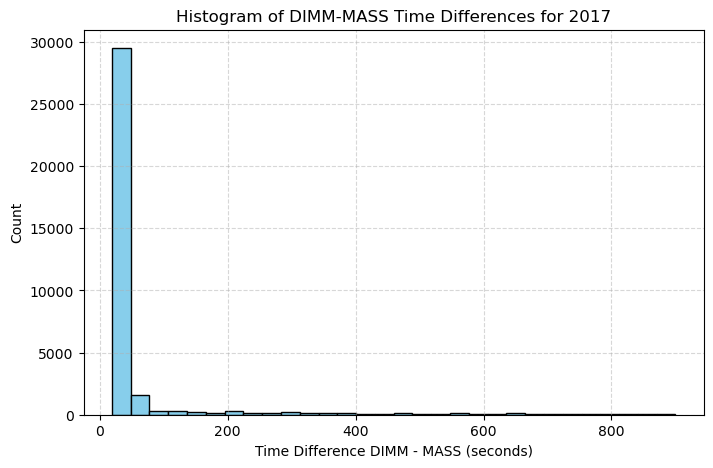

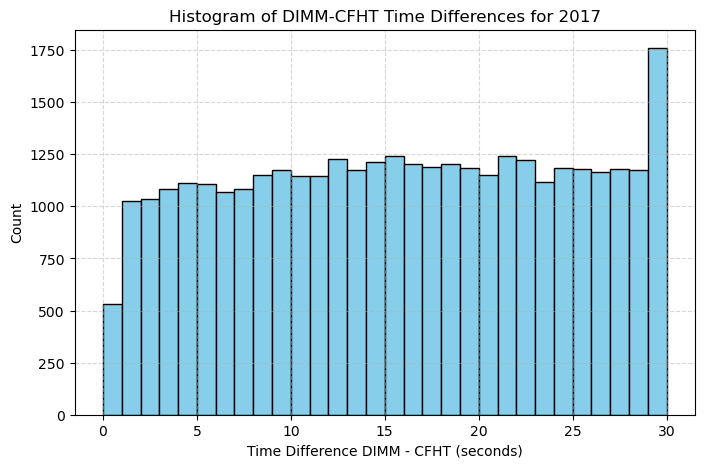

In [111]:
# Read CSV
df = pd.read_csv("2025_900sec.csv")

print("Number of Rows in file when tolerance = 30seconds: ", len(df))
print("Number of days accounted for: 216")

# Plot histogram of dt_dimm_mass
plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_mass'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - MASS (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-MASS Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_cfht'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - CFHT (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-CFHT Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Number of Rows in file when tolerance = 60seconds:  33674
Number of days accounted for: 216
Number of rows with dt_dimm_mass > 30: 13618
Number of rows with dt_dimm_cfht > 30: 0


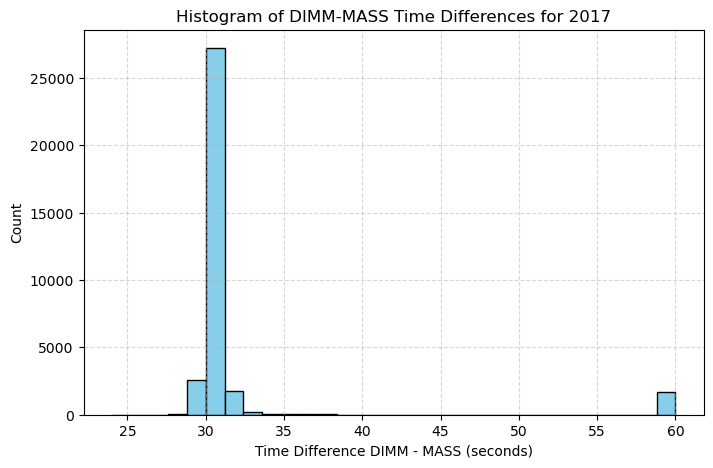

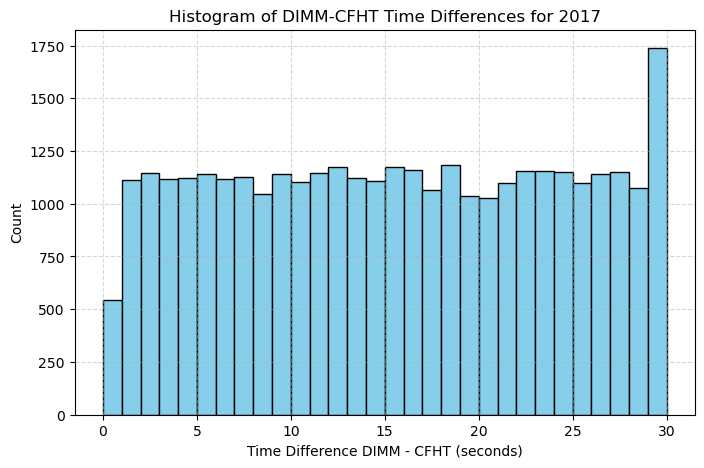

In [62]:
# Read CSV
df = pd.read_csv("2017_p2.csv")

print("Number of Rows in file when tolerance = 60seconds: ", len(df))
print("Number of days accounted for: 216")
count = df[df["dt_dimm_mass"] > 30].shape[0]
print("Number of rows with dt_dimm_mass > 30:", count)
count2 = df[df["dt_dimm_cfht"] > 30].shape[0]
print("Number of rows with dt_dimm_cfht > 30:", count2)

# Plot histogram of dt_dimm_mass
plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_mass'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - MASS (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-MASS Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_cfht'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - CFHT (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-CFHT Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Number of Rows in file when tolerance = 90seconds:  35120
Number of days accounted for: 216
Number of rows with dt_dimm_mass > 60: 1446
Number of rows with dt_dimm_cfht > 60: 0


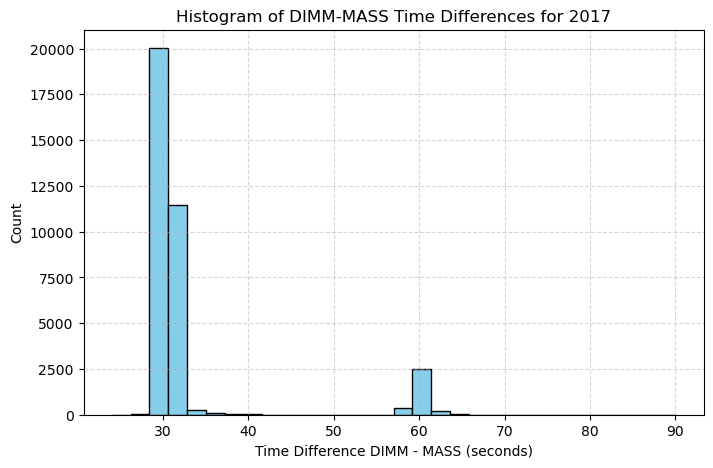

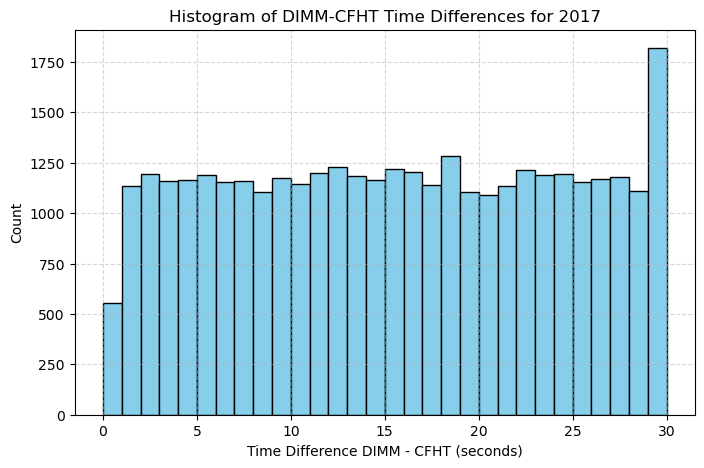

In [66]:
# Read CSV
df = pd.read_csv("2017_p3.csv")

print("Number of Rows in file when tolerance = 90seconds: ", len(df))
print("Number of days accounted for: 216")
count = df[df["dt_dimm_mass"] > 60].shape[0]
print("Number of rows with dt_dimm_mass > 60:", count)
count2 = df[df["dt_dimm_cfht"] > 60].shape[0]
print("Number of rows with dt_dimm_cfht > 60:", count2)

# Plot histogram of dt_dimm_mass
plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_mass'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - MASS (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-MASS Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_cfht'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - CFHT (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-CFHT Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Number of Rows in file when tolerance = 900seconds:  37263
Number of days accounted for: 216
Number of rows with dt_dimm_mass > 90: 2143
Number of rows with dt_dimm_cfht > 90: 0


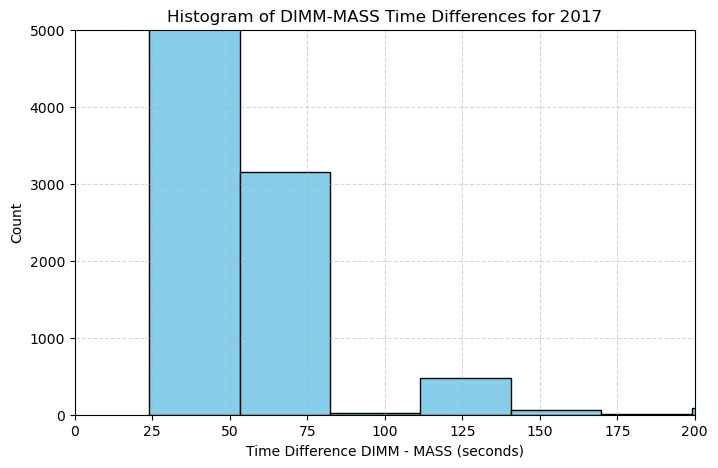

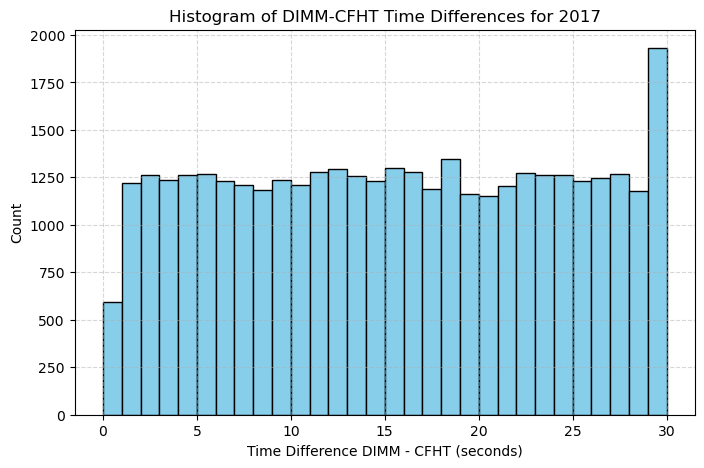

In [8]:
# Read CSV
df = pd.read_csv("2017_p4.csv")

print("Number of Rows in file when tolerance = 900seconds: ", len(df))
print("Number of days accounted for: 216")
count = df[df["dt_dimm_mass"] > 90].shape[0]
print("Number of rows with dt_dimm_mass > 90:", count)
count2 = df[df["dt_dimm_cfht"] > 90].shape[0]
print("Number of rows with dt_dimm_cfht > 90:", count2)

# Plot histogram of dt_dimm_mass
plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_mass'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - MASS (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-MASS Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0,5000)
plt.xlim(0,200)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['dt_dimm_cfht'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Time Difference DIMM - CFHT (seconds)')
plt.ylabel('Count')
plt.title('Histogram of DIMM-CFHT Time Differences for 2017')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()